  NETFLIX DATASET — OVERVIEW
Shape        : 1000 rows × 7 columns
Columns      : ['title', 'rating', 'ratinglevel', 'ratingdescription', 'release_year', 'user_rating_score', 'user_rating_size']

                   title rating  \
0           White Chicks  PG-13   
1    Lucky Number Slevin      R   
2         Grey's Anatomy  TV-14   
3           Prison Break  TV-14   
4  How I Met Your Mother  TV-PG   

                                         ratinglevel  ratingdescription  \
0  crude and sexual humor, language and some drug...                 80   
1  strong violence, sexual content and adult lang...                100   
2  Parents strongly cautioned. May be unsuitable ...                 90   
3  Parents strongly cautioned. May be unsuitable ...                 90   
4  Parental guidance suggested. May not be suitab...                 70   

   release_year  user_rating_score  user_rating_size  
0          2004               82.0                80  
1          2006                Na

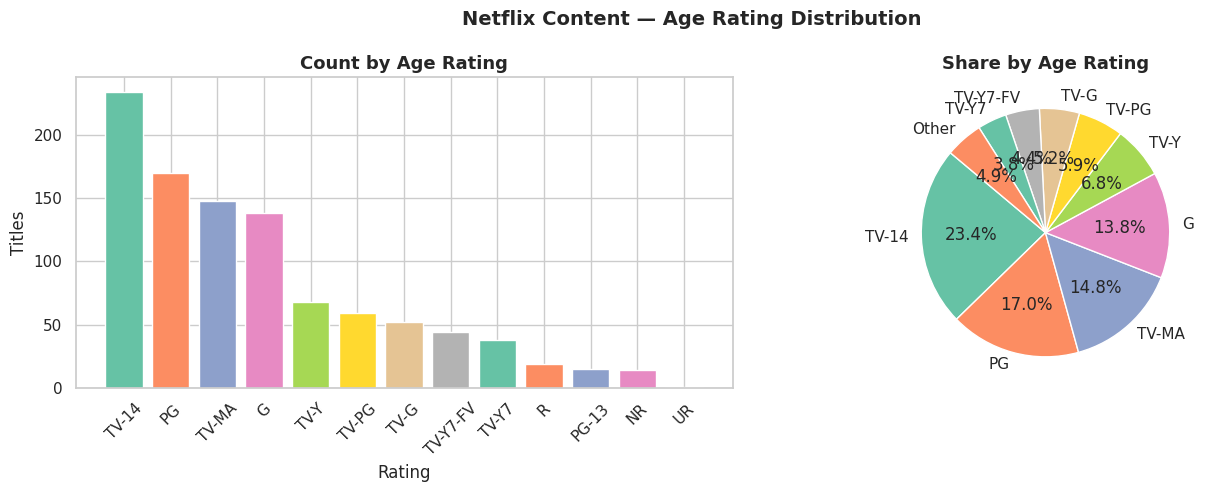

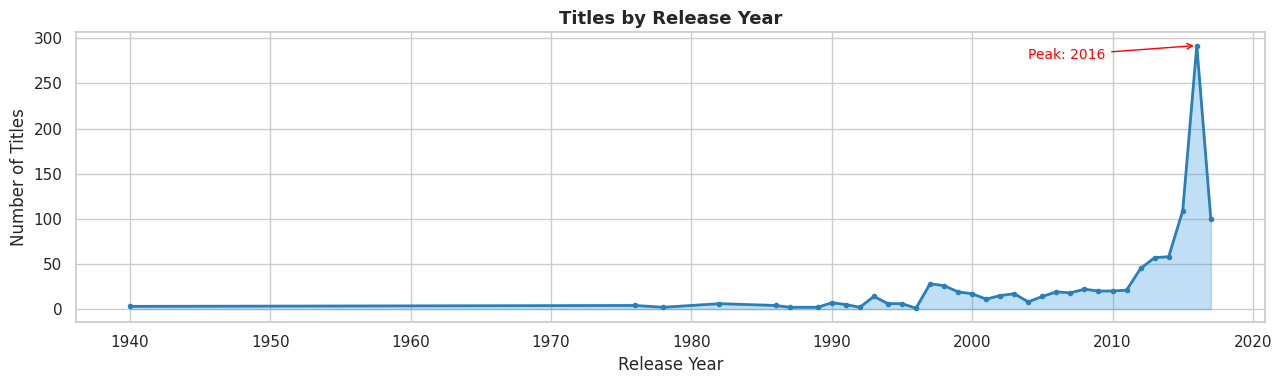

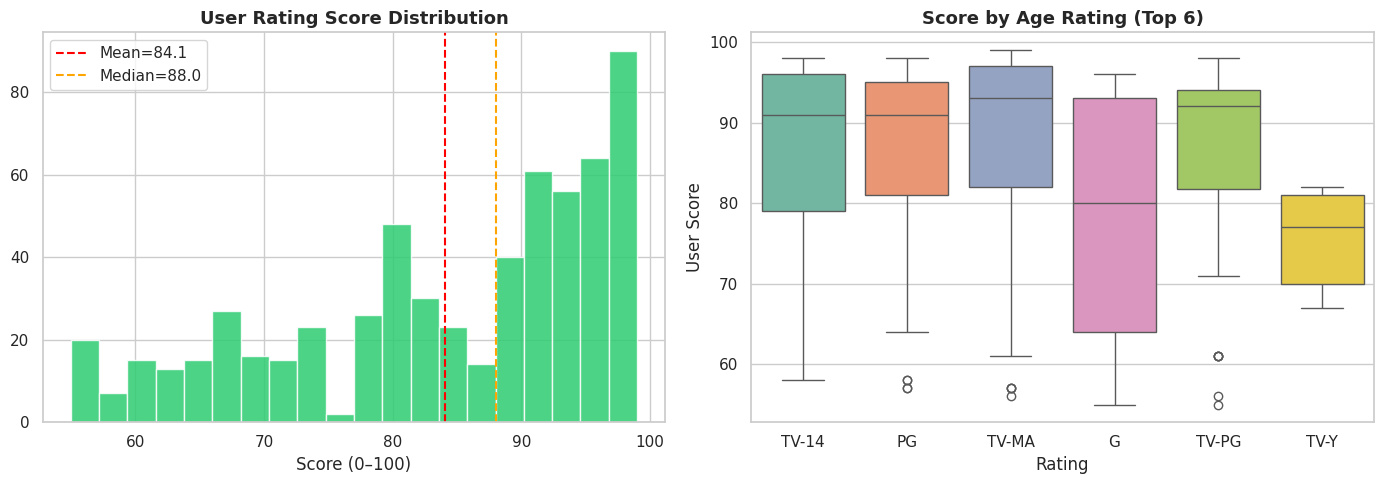

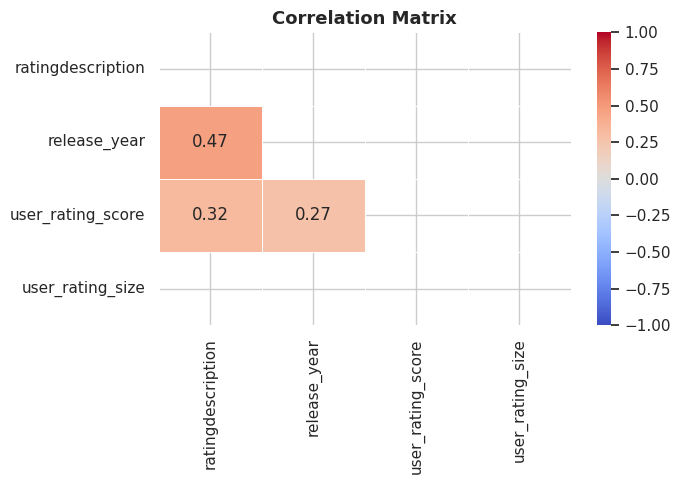

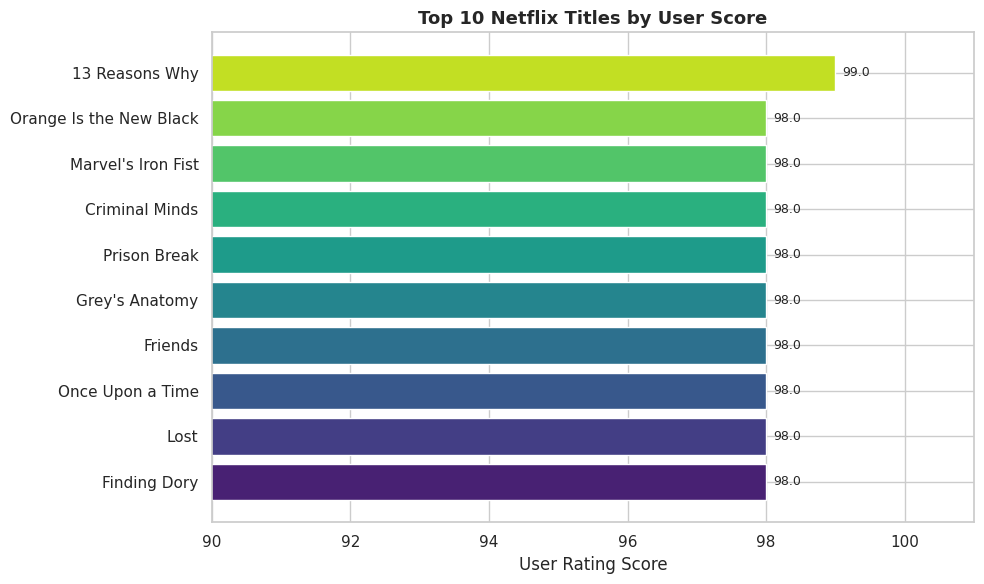


✅ All charts saved. Analysis complete!


In [1]:
# ============================================================
#  Netflix Content Analysis
#  Dataset: netflix.csv (1000 titles, 7 columns)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

# ── 1. LOAD DATA ─────────────────────────────────────────────
df = pd.read_csv("/content/netflix.csv")

print("=" * 55)
print("  NETFLIX DATASET — OVERVIEW")
print("=" * 55)
print(f"Shape        : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns      : {df.columns.tolist()}")
print()
print(df.head())
print()
print(df.dtypes)

# ── 2. MISSING VALUES ────────────────────────────────────────
print("\n" + "=" * 55)
print("  MISSING VALUES")
print("=" * 55)
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
print(pd.DataFrame({"missing_count": missing, "missing_%": missing_pct}))

# ── 3. BASIC STATISTICS ──────────────────────────────────────
print("\n" + "=" * 55)
print("  DESCRIPTIVE STATISTICS")
print("=" * 55)
print(df.describe(include="all"))

# ── 4. CLEAN DATA ────────────────────────────────────────────
df_clean = df.copy()
df_clean["ratinglevel"] = df_clean["ratinglevel"].fillna("Unknown")

# Subset with valid user scores for score-based analysis
df_rated = df_clean.dropna(subset=["user_rating_score"]).copy()

print(f"\nFull dataset : {len(df_clean)} rows")
print(f"Rated subset : {len(df_rated)} rows (user_rating_score available)")
print(f"Duplicates   : {df_clean.duplicated(subset='title').sum()}")

# ── 5. RATING DISTRIBUTION ───────────────────────────────────
print("\n" + "=" * 55)
print("  RATING DISTRIBUTION")
print("=" * 55)
print(df_clean["rating"].value_counts())

# ── 6. RELEASE YEAR STATS ────────────────────────────────────
print("\n" + "=" * 55)
print("  RELEASE YEAR STATS")
print("=" * 55)
print(df_clean["release_year"].describe())
print(f"\nTop 5 years by volume:\n{df_clean['release_year'].value_counts().head()}")

# ── 7. USER RATING SCORE ANALYSIS ───────────────────────────
print("\n" + "=" * 55)
print("  USER RATING SCORE STATS")
print("=" * 55)
print(df_rated["user_rating_score"].describe().round(2))

# ── 8. TOP 10 HIGHEST RATED TITLES ──────────────────────────
print("\n" + "=" * 55)
print("  TOP 10 HIGHEST RATED TITLES")
print("=" * 55)
top10 = (
    df_rated
    .sort_values("user_rating_score", ascending=False)
    .drop_duplicates("title")
    .head(10)[["title", "rating", "release_year", "user_rating_score"]]
    .reset_index(drop=True)
)
top10.index += 1
print(top10.to_string())

# ── 9. CORRELATION ───────────────────────────────────────────
print("\n" + "=" * 55)
print("  CORRELATION MATRIX (numeric columns)")
print("=" * 55)
numeric_cols = ["ratingdescription", "release_year", "user_rating_score", "user_rating_size"]
print(df_rated[numeric_cols].corr().round(3))

# ── 10. AVERAGE SCORE BY AGE RATING ─────────────────────────
print("\n" + "=" * 55)
print("  AVG USER SCORE BY AGE RATING")
print("=" * 55)
avg_score = (
    df_rated.groupby("rating")["user_rating_score"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_score", "count": "titles"})
    .sort_values("avg_score", ascending=False)
    .round(2)
)
print(avg_score)

# ── 11. VISUALISATIONS ───────────────────────────────────────

# Fig 1 — Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rating_counts = df_clean["rating"].value_counts()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=sns.color_palette("Set2", len(rating_counts)), edgecolor="white")
axes[0].set_title("Count by Age Rating", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Titles")
axes[0].tick_params(axis="x", rotation=45)

threshold = 30
top = rating_counts[rating_counts >= threshold]
other = pd.Series({"Other": rating_counts[rating_counts < threshold].sum()})
pie_data = pd.concat([top, other])
axes[1].pie(pie_data, labels=pie_data.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2", len(pie_data)), startangle=140)
axes[1].set_title("Share by Age Rating", fontsize=13, fontweight="bold")
plt.suptitle("Netflix Content — Age Rating Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=120, bbox_inches="tight")  # saved in same folder as script
plt.show()

# Fig 2 — Release year trend
fig, ax = plt.subplots(figsize=(13, 4))
year_counts = df_clean["release_year"].value_counts().sort_index()
ax.fill_between(year_counts.index, year_counts.values, alpha=0.3, color="#3498db")
ax.plot(year_counts.index, year_counts.values, color="#2980b9", linewidth=2,
        marker="o", markersize=3)
peak_year = year_counts.idxmax()
ax.annotate(f"Peak: {peak_year}", xy=(peak_year, year_counts.max()),
            xytext=(peak_year - 12, year_counts.max() - 15),
            arrowprops=dict(arrowstyle="->", color="red"), color="red", fontsize=10)
ax.set_title("Titles by Release Year", fontsize=13, fontweight="bold")
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Titles")
plt.tight_layout()
plt.savefig("release_year_trend.png", dpi=120, bbox_inches="tight")
plt.show()

# Fig 3 — User rating score distribution + box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_rated["user_rating_score"], bins=20, color="#2ecc71",
             edgecolor="white", alpha=0.85)
axes[0].axvline(df_rated["user_rating_score"].mean(), color="red",
                linestyle="--", label=f"Mean={df_rated['user_rating_score'].mean():.1f}")
axes[0].axvline(df_rated["user_rating_score"].median(), color="orange",
                linestyle="--", label=f"Median={df_rated['user_rating_score'].median():.1f}")
axes[0].set_title("User Rating Score Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Score (0–100)")
axes[0].legend()

top6 = df_rated["rating"].value_counts().head(6).index
sns.boxplot(data=df_rated[df_rated["rating"].isin(top6)],
            x="rating", y="user_rating_score", order=top6,
            palette="Set2", ax=axes[1])
axes[1].set_title("Score by Age Rating (Top 6)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("User Score")
plt.tight_layout()
plt.savefig("user_rating_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

# Fig 4 — Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = df_rated[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

# Fig 5 — Top 10 rated titles
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10["title"][::-1], top10["user_rating_score"][::-1],
               color=sns.color_palette("viridis", 10))
ax.set_xlim(90, 101)
ax.set_xlabel("User Rating Score")
ax.set_title("Top 10 Netflix Titles by User Score", fontsize=13, fontweight="bold")
for bar, score in zip(bars, top10["user_rating_score"][::-1]):
    ax.text(score + 0.1, bar.get_y() + bar.get_height() / 2,
            str(score), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("top10_titles.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n✅ All charts saved. Analysis complete!")